# Random MIDI analysis: Spillage of polyphony + plots

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import random
import matplotlib.pyplot as plt
import pretty_midi as pm
from tqdm import tqdm

import sys
sys.path.append('..')
from utils import get_polyphony_degrees

In [2]:
pitch_min = 21
pitch_max = 108

def sample_pitch(pitch_min, pitch_max):
    return random.randint(pitch_min, pitch_max)

duration_min = 0.01
duration_max = 5.

def sample_duration(duration_min, duration_max, alpha=2, beta=5):
    return random.betavariate(alpha, beta) * (duration_max-duration_min) + duration_min

dynamics_ranges = {
    0: {'velocity_min': 60, 'velocity_max': 68}, # easy - no dynamics (all mezzo-forte)
    1: {'velocity_min': 32, 'velocity_max': 96}, # medium - some dynamics (piano to forte)
    2: {'velocity_min': 1, 'velocity_max': 127}  # hard - full dynamics (piano pianissimo to forte fortissimo)
}

def sample_velocity(dynamics_range):
    return random.randint(dynamics_range['velocity_min'], dynamics_range['velocity_max'])

polyphony_min = 1
polyphony_max = 24

polyphony_degrees = list(range(polyphony_min, polyphony_max+1))

D = len(dynamics_ranges) # dynamics ranges
P = len(polyphony_degrees) # number of polyphony degrees to be explored
T = 2 # minutes per piece
print('| P =', P, '| T =', T, '| D =', D, '| P * T * D =', P * T * D, 'minutes.')

piece_duration = T * 60. # 120 seconds

| P = 24 | T = 2 | D = 3 | P * T * D = 144 minutes.


In [3]:
def overlaps(note_a, note_b):
    return (min(note_a.end, note_b.end) - max(note_a.start, note_b.start)) > 0

def generate_random_piece(polyphony_deg, dynamics_range, piece_duration, discontinuous_voices=True, seed=0):
    assert polyphony_deg > 0
    random.seed(seed)

    # create a PrettyMIDI object for the piece
    piece = pm.PrettyMIDI(resolution=480)
    # create an Instrument instance for the piano instrument
    piano_program = pm.instrument_name_to_program('Acoustic Grand Piano') # 0
    piano = pm.Instrument(program=piano_program)

    # for each voice of the polyphony
    for voice in range(polyphony_deg):
        # populate the voice with notes
        t_playhead = 0.
        while t_playhead < piece_duration:
            # keep resampling the new note until one is found that doesn't overlap
            # with any of the existing notes
            while True:
                velocity = sample_velocity(dynamics_range)
                pitch = sample_pitch(pitch_min, pitch_max)
                duration = sample_duration(duration_min, duration_max)
                new_note = pm.Note(velocity=velocity, pitch=pitch, start=t_playhead, end=t_playhead+duration)

                equal_pitch_notes = [note for note in piano.notes if note.pitch == new_note.pitch]
                if not any(overlaps(new_note, note) for note in equal_pitch_notes):
                    break
                else:
                    # TODO in script as logging.log(logging.INFO, text)
                    #print(f'collision in voice {voice}: pitch {pitch} at time {new_note.start:.2f}-{new_note.end:.2f} [s] overlaps. resampling...')
                    pass
            
            # trim the duration of the new note, if it would extend beyond the piece duration
            if t_playhead + duration > piece_duration:
                duration = piece_duration - t_playhead
                new_note.end = t_playhead + duration
                t_playhead = piece_duration # ensure breaking the loop for this voice (prevent float precision issues)
            else:
                t_playhead += duration
            
            # add the new note to the piano instrument
            piano.notes.append(new_note)
    
    if discontinuous_voices:
        # randomize discontinuity of voices by trimming the notes by 
        # up to 1% of their durations on both start and end times
        for note in piano.notes[1:-1]:
            # note.duration changes together with note.start and note.end
            note_duration = note.duration
            note.start += random.uniform(0.0, 0.01 * note_duration)
            note.end -= random.uniform(0.0, 0.01 * note_duration)
            
    # add the piano instrument to the piece
    piece.instruments.append(piano)
    return piece

# test execution
piece = generate_random_piece(1, dynamics_ranges[0], piece_duration)

In [4]:
pieces_all = {}
for polyphony_deg in tqdm(polyphony_degrees):
    for dyn_level in dynamics_ranges.keys():
        config_string = f'RANDOM_P{polyphony_deg:02d}_D{dyn_level:01d}'
        piece = generate_random_piece(polyphony_deg, dynamics_ranges[dyn_level], piece_duration)
        pieces_all[config_string] = piece

100%|██████████| 24/24 [00:04<00:00,  5.98it/s]


All 3 dynamics levels (stats from 72 pieces)

In [6]:
poly_matrix = []
for poly_level in tqdm(range(polyphony_min, polyphony_max+1)):
    polyphonies = []
    for dyn_level in dynamics_ranges.keys():
        piece = generate_random_piece(poly_level, dynamics_ranges[dyn_level], piece_duration)
        piece_polyphonies = get_polyphony_degrees(piece.instruments[0], fs=100, events_only=False)
        polyphonies.append(piece_polyphonies)
    polyphonies = np.concatenate(polyphonies)
    poly_frame_counts = [sum(polyphonies == p) for p in range(polyphony_min, polyphony_max+1)]
    poly_matrix.append(poly_frame_counts)
poly_matrix = np.array(poly_matrix)

100%|██████████| 24/24 [00:05<00:00,  4.35it/s]


### Figure 26

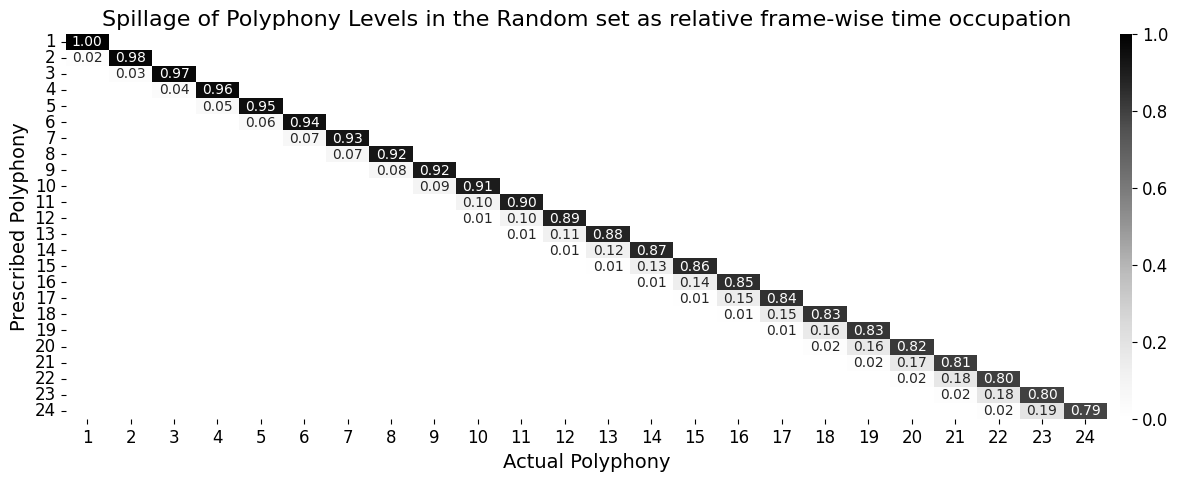

In [7]:
import seaborn as sns
from matplotlib.colors import LogNorm

fs_title=16
fs_axis=14
fs_ticks=12

# Convert to relative values (percentages)
row_sums = poly_matrix.sum(axis=1, keepdims=True)
relative_poly_matrix = poly_matrix / row_sums

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(relative_poly_matrix + 1e-10, annot=True, fmt='.2f', cmap='Greys', cbar_kws={'pad': 0.01, 'aspect': 30})
ax.collections[0].colorbar.ax.tick_params(labelsize=fs_ticks)

# Remove annotations for values smaller than 0.01
for text in ax.texts:
    value = float(text.get_text())
    if value < 0.01:
        text.set_text('')

plt.xlabel('Actual Polyphony', fontsize=fs_axis)
plt.ylabel('Prescribed Polyphony', fontsize=fs_axis)
plt.title('Spillage of Polyphony Levels in the Random set as relative frame-wise time occupation', fontsize=fs_title)
# Relabel axes to start with 1 instead of 0
plt.xticks(ticks=np.arange(poly_matrix.shape[1]) + 0.5, labels=np.arange(1, poly_matrix.shape[1] + 1), fontsize=fs_ticks)
plt.yticks(ticks=np.arange(poly_matrix.shape[0]) + 0.5, labels=np.arange(1, poly_matrix.shape[0] + 1), fontsize=fs_ticks, rotation=0)

# fig.savefig('../paper/figs/A10_random_polyphony_spillage_heatmap.pdf', bbox_inches='tight')
plt.show()

## Plot a sample from Random set depicting the 3 dynamics levels

### Figure 25

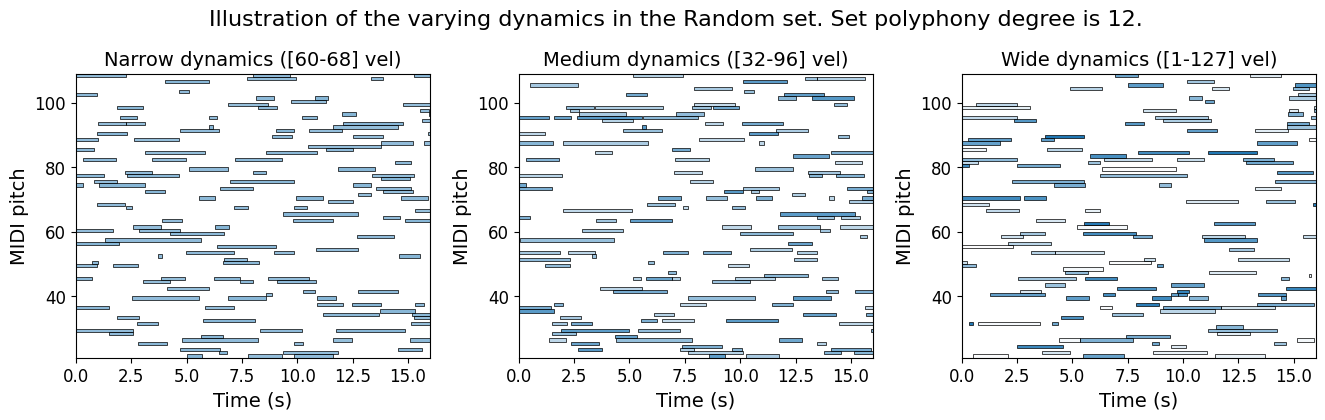

In [8]:
from utils import get_rgba

def plot_custom_piano_roll(ax, pm_midi, facecolor='tab:blue', note_alpha=None):
    # piano roll
    for note in sum([instr.notes for instr in pm_midi.instruments], []):
        ax.add_patch(plt.Rectangle(
            (note.start, note.pitch), note.end - note.start, 1.0, facecolor=get_rgba(facecolor, note_alpha or note.velocity / 127.),
            edgecolor='black', linewidth=0.5, linestyle='-', hatch=None))

    # axes limits and labels
    ax.set(xlim=(0, T), ylim=(pm.note_name_to_number('A0'), pm.note_name_to_number('C8')+1), xlabel='Time (s)', ylabel='MIDI pitch')
    ax.tick_params(axis='both', labelsize=fs_ticks)
    # set axis labels font size
    ax.xaxis.label.set_size(fs_axis)
    ax.yaxis.label.set_size(fs_axis)

P = 12
T = 16

fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=False, gridspec_kw={'wspace': 0.25})

for i in range(3):
    piece = generate_random_piece(P, dynamics_ranges[i], T)
    plot_custom_piano_roll(axs[i], piece)
    # axs[i].set_title(f'Dynamics level {i}: [{list(dynamics_ranges[i].values())[0]}-{list(dynamics_ranges[i].values())[1]}] vel');
axs[0].set_title(f'Narrow dynamics ([{list(dynamics_ranges[0].values())[0]}-{list(dynamics_ranges[0].values())[1]}] vel)', fontsize=fs_axis);
axs[1].set_title(f'Medium dynamics ([{list(dynamics_ranges[1].values())[0]}-{list(dynamics_ranges[1].values())[1]}] vel)', fontsize=fs_axis);
axs[2].set_title(f'Wide dynamics ([{list(dynamics_ranges[2].values())[0]}-{list(dynamics_ranges[2].values())[1]}] vel)', fontsize=fs_axis);

fig.suptitle(f'Illustration of the varying dynamics in the Random set. Set polyphony degree is {P}.', fontsize=fs_title)
plt.subplots_adjust(top=0.82)

# fig.savefig('../paper/figs/A09_random_dynamics_showcase.pdf', bbox_inches='tight')
plt.show()

# END